# CS108/212 STAT108/212 W26 Course Project

### Team Details

- Teammate 1: Xiyuan Wu
- Teammate 2: Daniel Maciel
- Teammate 3: Byron Bhuiyan

# Milestone: Mitigating Bias
For this project milestone, each teammate will implement bias mitigation strategies and assess pre and post bias mitigation performance.

# Installs

In [2]:
!pip install fairlearn -q

# Imports

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import collections
from pprint import pprint
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, confusion_matrix
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference, MetricFrame
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.tree import DecisionTreeClassifier

# Loading dataset
_(same as previous milestone, copy-paste)_

In [4]:
df = pd.read_csv("../fair_recrutment_dataset final.csv")


df = df.dropna().drop_duplicates().reset_index(drop=True)

X = df.drop(['Hiring_Decision', 'Candidate_ID'], axis=1)   # features
y = df['Hiring_Decision']                                   # target
sensitive_feature_colname = ['Gender', 'Age_Group']         # both sensitive features


group_labels = None

print(f"No. of samples: {df.shape[0]}")
print(f"No. of features: {X.shape[1]}")
print(df['Hiring_Decision'].value_counts().rename({0: 'Not Hired', 1: 'Hired'}))

No. of samples: 119971
No. of features: 14
Hiring_Decision
Not Hired    89086
Hired        30885
Name: count, dtype: int64


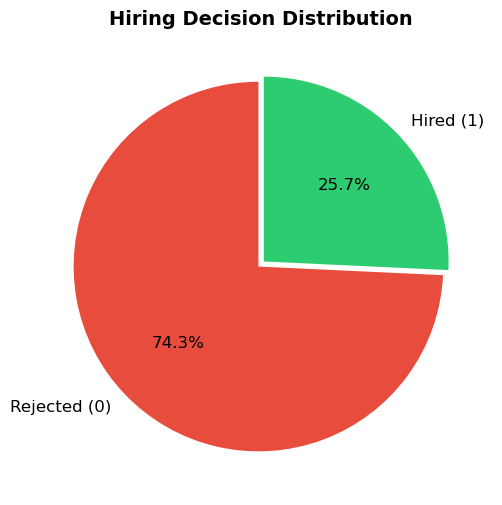

Total Candidates: 119,971
Hired:    30,885 (25.7%)
Rejected: 89,086 (74.3%)


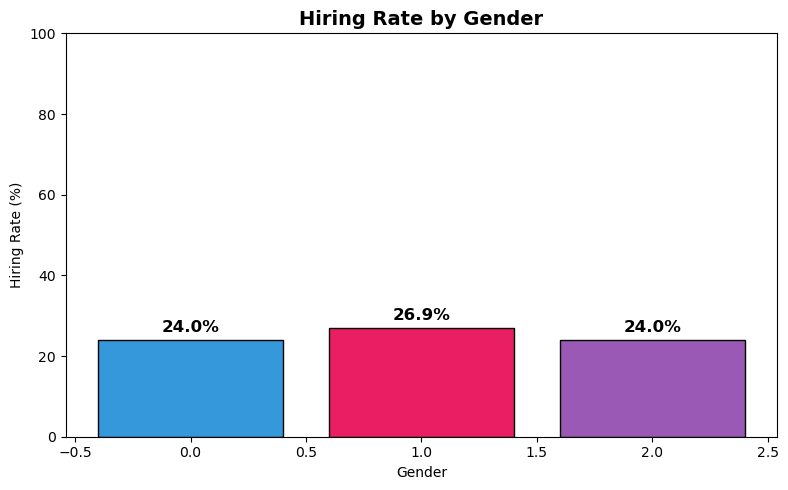

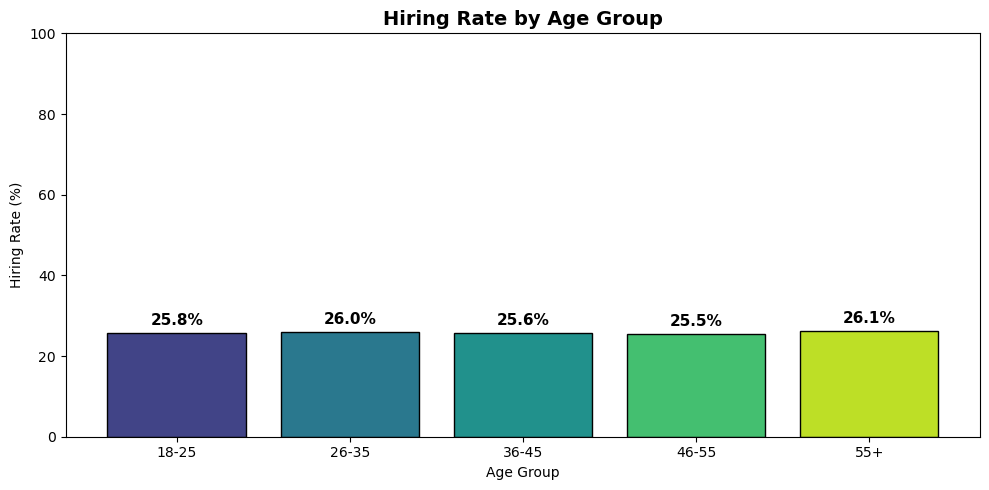

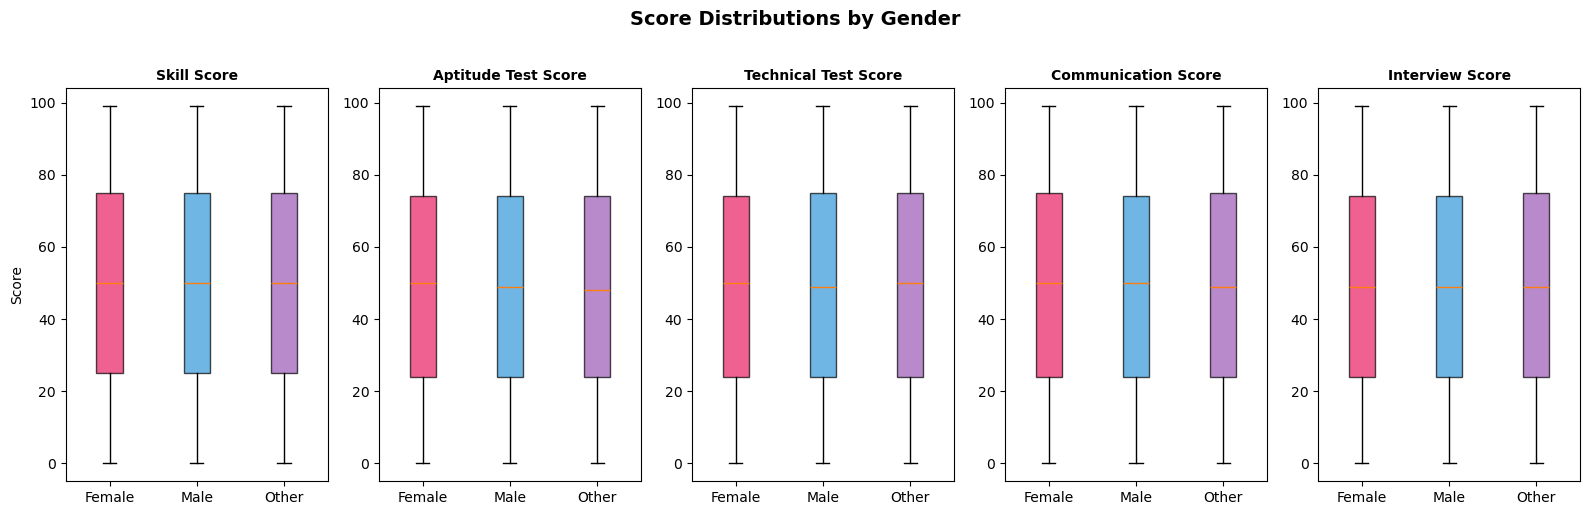

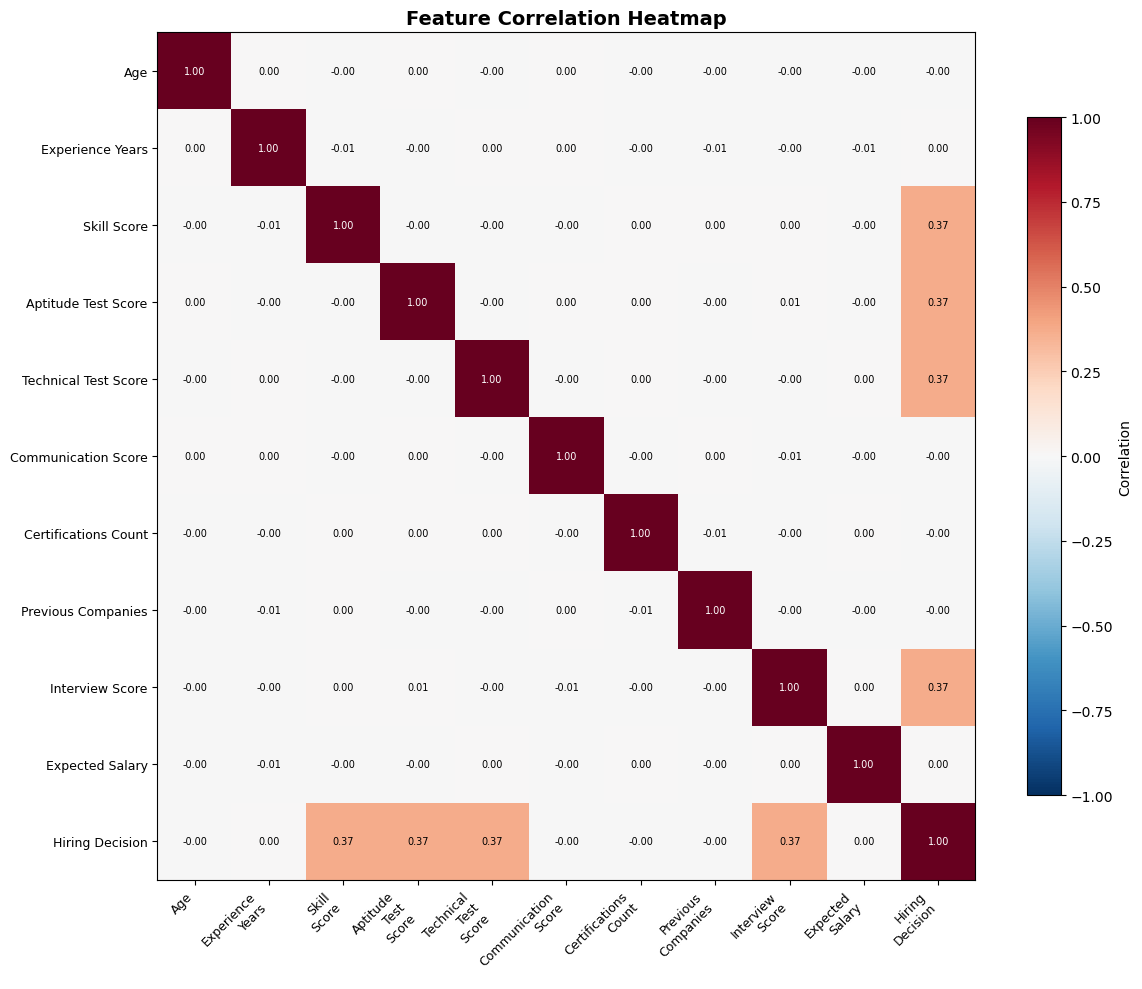

In [21]:

hiring_counts = df["Hiring_Decision"].value_counts()
colors = ["#e74c3c", "#2ecc71"]
labels_pie = ["Rejected (0)", "Hired (1)"]
gender_map = {0: "Female", 1: "Male", 2: "Other"}
df["Gender_Label"] = df["Gender"].map(gender_map)
plt.figure(figsize=(6, 6))
plt.pie([hiring_counts[0], hiring_counts[1]], labels=labels_pie, colors=colors,
        autopct="%1.1f%%", startangle=90, explode=(0.02, 0.02),
        textprops={"fontsize": 12})
plt.title("Hiring Decision Distribution", fontsize=14, fontweight="bold")
plt.show()

print(f"Total Candidates: {len(df):,}")
print(f"Hired:    {hiring_counts[1]:,} ({hiring_counts[1]/len(df)*100:.1f}%)")
print(f"Rejected: {hiring_counts[0]:,} ({hiring_counts[0]/len(df)*100:.1f}%)")
gender_hiring = df.groupby("Gender")["Hiring_Decision"].agg(["sum", "count"])
gender_hiring["Hiring_Rate"] = (gender_hiring["sum"] / gender_hiring["count"] * 100).round(1)
gender_hiring = gender_hiring.reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(gender_hiring["Gender"], gender_hiring["Hiring_Rate"],
               color=["#3498db", "#e91e63", "#9b59b6"], edgecolor="black")
plt.title("Hiring Rate by Gender", fontsize=14, fontweight="bold")
plt.ylabel("Hiring Rate (%)"); plt.xlabel("Gender"); plt.ylim(0, 100)
for bar, rate in zip(bars, gender_hiring["Hiring_Rate"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{rate}%", ha="center", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()
_bins  = [0, 25, 35, 45, 55, 100]
_labs  = ["18-25", "26-35", "36-45", "46-55", "55+"]
df["Age_Group_EDA"] = pd.cut(df["Age"], bins=_bins, labels=_labs)

age_hiring = df.groupby("Age_Group_EDA", observed=True)["Hiring_Decision"].agg(["sum", "count"])
age_hiring["Hiring_Rate"] = (age_hiring["sum"] / age_hiring["count"] * 100).round(1)
age_hiring = age_hiring.reset_index()

plt.figure(figsize=(10, 5))
colors_age = plt.cm.viridis([0.2, 0.4, 0.5, 0.7, 0.9])
bars = plt.bar(age_hiring["Age_Group_EDA"], age_hiring["Hiring_Rate"],
               color=colors_age, edgecolor="black")
plt.title("Hiring Rate by Age Group", fontsize=14, fontweight="bold")
plt.ylabel("Hiring Rate (%)"); plt.xlabel("Age Group"); plt.ylim(0, 100)
for bar, rate in zip(bars, age_hiring["Hiring_Rate"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f"{rate}%", ha="center", fontweight="bold", fontsize=11)
plt.tight_layout(); plt.show()

df.drop(columns=["Age_Group_EDA"], inplace=True)  # clean up temp column

score_columns = ["Skill_Score", "Aptitude_Test_Score", "Technical_Test_Score",
                 "Communication_Score", "Interview_Score"]

fig, axes = plt.subplots(1, 5, figsize=(16, 5))

groups = ["Female", "Male", "Other"]
colors = ["#e91e63", "#3498db", "#9b59b6"]

for idx, col in enumerate(score_columns):
    data = [df[df["Gender_Label"] == g][col] for g in groups]

    bp = axes[idx].boxplot(data, tick_labels=groups, patch_artist=True)

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[idx].set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    axes[idx].set_ylabel("Score" if idx == 0 else "")

plt.suptitle("Score Distributions by Gender", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
numerical_cols = ["Age", "Experience_Years", "Skill_Score", "Aptitude_Test_Score",
                  "Technical_Test_Score", "Communication_Score", "Certifications_Count",
                  "Previous_Companies", "Interview_Score", "Expected_Salary", "Hiring_Decision"]

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
cmap = plt.cm.RdBu_r
im = plt.imshow(corr_matrix, cmap=cmap, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation", shrink=0.8)
plt.xticks(range(len(numerical_cols)),
           [c.replace("_", "\n") for c in numerical_cols], rotation=45, ha="right", fontsize=9)
plt.yticks(range(len(numerical_cols)),
           [c.replace("_", " ") for c in numerical_cols], fontsize=9)
for i in range(len(numerical_cols)):
    for j in range(len(numerical_cols)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.5 else "black"
        plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7, color=color)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# Preparing dataset
_(same as previous milestone, copy-paste)_

In [6]:

edu_map = {'High School': 0, 'Diploma': 1, 'Bachelors': 2, 'Masters': 3, 'PhD': 4}
df['Education_Level'] = df['Education_Level'].map(edu_map)


df['Gender']           = LabelEncoder().fit_transform(df['Gender'])
df['Location']         = LabelEncoder().fit_transform(df['Location'])
df['Job_Role_Applied'] = LabelEncoder().fit_transform(df['Job_Role_Applied'])

bins = [20, 25, 35, 45, 55, 60]
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=[0, 1, 2, 3, 4],
                          include_lowest=True).astype(int)

X = df.drop(['Hiring_Decision', 'Candidate_ID'], axis=1)

group_labels = df['Gender'].astype(str) + '_age' + df['Age_Group'].astype(str)

print("Encoding complete. Sample group labels:")
print(group_labels.value_counts().head(8))

Encoding complete. Sample group labels:
1_age2    18460
1_age3    18416
1_age1    18323
0_age2    10854
0_age3    10771
0_age1    10697
1_age0     9264
1_age4     7478
Name: count, dtype: int64


# Getting training and testing sets

Note: Train-test split is made **ONCE** to obtain the _training set_ and the _testing set_ and every teammate will use the training set to train their baseline model and test the trained model using the testing set. **NEVER** modify the testing set once it has been created.
Therefore, the following code cell does not need to be edited.

_(same as previous milestone, copy-paste)_

In [7]:
X_train, X_test, \
  y_train, y_test, \
    group_labels_train, group_labels_test = train_test_split(X, y, group_labels,
                                                             test_size=0.2, random_state=42)

print(f"No. of training samples: {X_train.shape[0]}")
print(f"No. of testing samples: {X_test.shape[0]}")

# Delete X, y and group_label variables to make sure they are not used later on.
del X
del y
del group_labels

No. of training samples: 95976
No. of testing samples: 23995


# Setting up evaluation metrics
Note: The same evaluation function will be used by all teammates.

_(same as previous milestone, copy-paste)_

In [8]:
def evaluate_model(y_test, y_pred, g_labels):

    results = {}

    # Task-specific performance metrics
    results['accuracy'] = accuracy_score(y_test, y_pred)
    results['f1_score'] = f1_score(y_test, y_pred)

    # Fairness metrics across Gender x Age_Group groups
    results['demographic_parity_diff'] = demographic_parity_difference(
        y_test, y_pred, sensitive_features=g_labels)
    results['equalized_odds_diff'] = equalized_odds_difference(
        y_test, y_pred, sensitive_features=g_labels)

    return results

# Training baseline models (INDIVIDUAL CONTRIBUTION)
_(minor modifications from previous milestone)_

In [9]:
## A place to save all teammates's baseline results
all_baseline_results = [] ## DO NOT EDIT

## Teammate 1

{'accuracy': 0.9596582621379454,
 'demographic_parity_diff': 0.0689329176304938,
 'equalized_odds_diff': 0.08784021071115011,
 'experiment_type': 'baseline',
 'f1_score': 0.9223487887052784,
 'mitigation_strategy': 'none',
 'predictor_model': 'Decision Tree',
 'teammate': 'Teammate 1'}


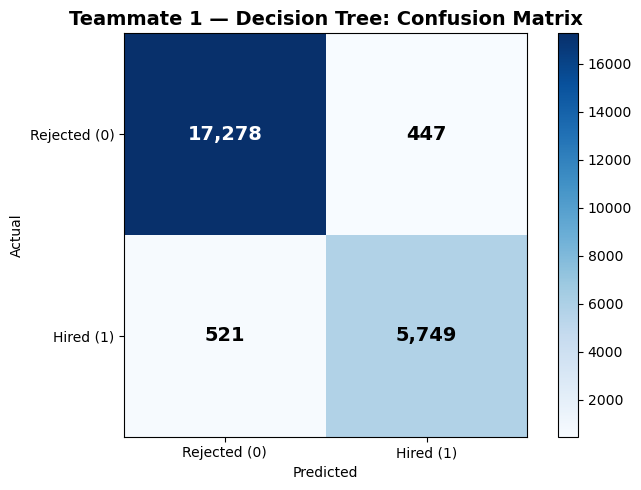

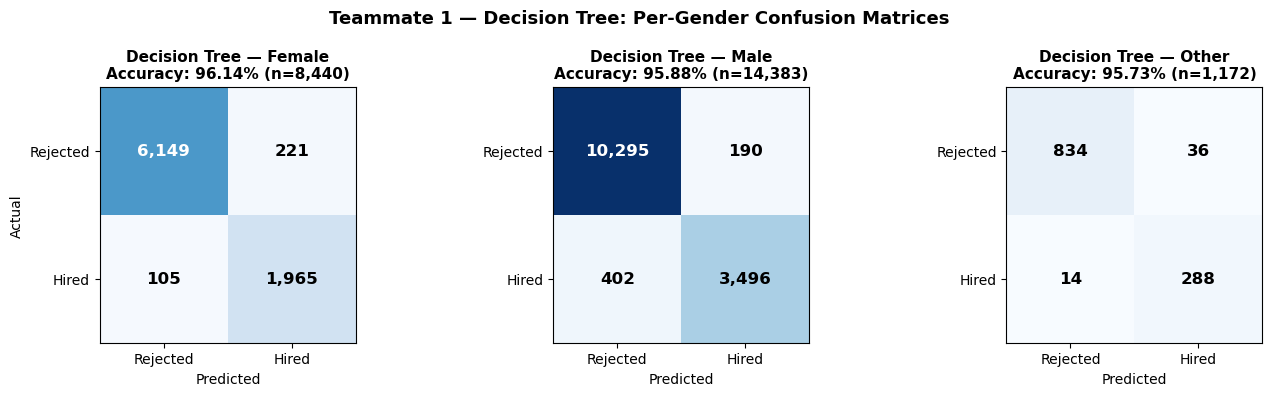

FAIRNESS METRICS BY GENDER — Decision Tree
        TPR (Recall)     FPR     FNR  TNR (Specificity)  PPV (Precision)  Accuracy  Selection Rate
Gender                                                                                            
Female        0.9493  0.0347  0.0507             0.9653           0.8989    0.9614          0.2590
Male          0.8969  0.0181  0.1031             0.9819           0.9485    0.9588          0.2563
Other         0.9536  0.0414  0.0464             0.9586           0.8889    0.9573          0.2765

DISPARITY ANALYSIS (Max difference across groups)
TPR (Recall)        : 0.0567  ⚠ Unfair
FPR                 : 0.0233  ✓ Fair
FNR                 : 0.0567  ⚠ Unfair
TNR (Specificity)   : 0.0233  ✓ Fair
PPV (Precision)     : 0.0596  ⚠ Unfair
Accuracy            : 0.0041  ✓ Fair
Selection Rate      : 0.0202  ✓ Fair

FAIRNESS CRITERIA EVALUATION
Equal Opportunity (TPR parity):      ✗ FAIL (diff=0.0567)
Equalized Odds (TPR + FPR parity):   ✗ FAIL (TPR=0.0567, F

In [10]:
# Decision Tree Baseline
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=1)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)


results = evaluate_model(y_test, y_pred, group_labels_test)


results['teammate']            = 'Teammate 1'
results['experiment_type']     = 'baseline'
results['predictor_model']     = 'Decision Tree'
results['mitigation_strategy'] = 'none'
all_baseline_results.append(results)

pprint(results)


conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
plt.imshow(conf_matrix, cmap="Blues")
plt.colorbar()
plt.title("Teammate 1 — Decision Tree: Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks([0, 1], ["Rejected (0)", "Hired (1)"])
plt.yticks([0, 1], ["Rejected (0)", "Hired (1)"])
for i in range(2):
    for j in range(2):
        color = "white" if conf_matrix[i, j] > conf_matrix.max()/2 else "black"
        plt.text(j, i, f"{conf_matrix[i, j]:,}", ha="center", va="center",
                 color=color, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


gender_labels_map = {0: "Female", 1: "Male", 2: "Other"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
all_cms = [confusion_matrix(y_test[X_test["Gender"] == g],
                             y_pred[X_test["Gender"] == g])
           for g in gender_labels_map]
vmax = max(cm.max() for cm in all_cms)

for idx, (g_code, g_name) in enumerate(gender_labels_map.items()):
    mask = X_test["Gender"] == g_code
    cm_g = confusion_matrix(y_test[mask], y_pred[mask])
    acc_g = (cm_g[0,0] + cm_g[1,1]) / cm_g.sum()
    im = axes[idx].imshow(cm_g, cmap="Blues", vmin=0, vmax=vmax)
    axes[idx].set_title(f"Decision Tree — {g_name}\nAccuracy: {acc_g:.2%} (n={mask.sum():,})",
                        fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Predicted"); axes[idx].set_ylabel("Actual" if idx == 0 else "")
    axes[idx].set_xticks([0,1]); axes[idx].set_xticklabels(["Rejected","Hired"])
    axes[idx].set_yticks([0,1]); axes[idx].set_yticklabels(["Rejected","Hired"])
    for i in range(2):
        for j in range(2):
            color = "white" if cm_g[i,j] > vmax/2 else "black"
            axes[idx].text(j, i, f"{cm_g[i,j]:,}", ha="center", va="center",
                          color=color, fontsize=12, fontweight="bold")
plt.suptitle("Teammate 1 — Decision Tree: Per-Gender Confusion Matrices",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


from sklearn.metrics import confusion_matrix as _cm

fairness_rows = []
for g_code, g_name in gender_labels_map.items():
    mask = X_test["Gender"] == g_code
    tn, fp, fn, tp = _cm(y_test[mask], y_pred[mask]).ravel()
    fairness_rows.append({
        "Gender":            g_name,
        "TPR (Recall)":      tp/(tp+fn) if (tp+fn) > 0 else 0,
        "FPR":               fp/(fp+tn) if (fp+tn) > 0 else 0,
        "FNR":               fn/(fn+tp) if (fn+tp) > 0 else 0,
        "TNR (Specificity)": tn/(tn+fp) if (tn+fp) > 0 else 0,
        "PPV (Precision)":   tp/(tp+fp) if (tp+fp) > 0 else 0,
        "Accuracy":          (tp+tn)/(tp+tn+fp+fn),
        "Selection Rate":    (tp+fp)/(tp+tn+fp+fn),
    })

fairness_df = pd.DataFrame(fairness_rows).set_index("Gender").round(4)
print("=" * 60)
print("FAIRNESS METRICS BY GENDER — Decision Tree")
print("=" * 60)
print(fairness_df.to_string())
print("\n" + "="*60)
print("DISPARITY ANALYSIS (Max difference across groups)")
print("="*60)
disparity = {}
for metric in fairness_df.columns:
    values = fairness_df[metric].values
    diff = max(values) - min(values)
    disparity[metric] = diff
    status = "✓ Fair" if diff < 0.05 else "⚠ Unfair" if diff < 0.1 else "✗ Biased"
    print(f"{metric:20s}: {diff:.4f}  {status}")


print("\n" + "="*60)
print("FAIRNESS CRITERIA EVALUATION")
print("="*60)
tpr_diff = disparity["TPR (Recall)"]
fpr_diff = disparity["FPR"]
ppv_diff = disparity["PPV (Precision)"]
sr_diff  = disparity["Selection Rate"]

print(f"Equal Opportunity (TPR parity):      {'✓ PASS' if tpr_diff < 0.05 else '✗ FAIL'} (diff={tpr_diff:.4f})")
print(f"Equalized Odds (TPR + FPR parity):   {'✓ PASS' if tpr_diff < 0.05 and fpr_diff < 0.05 else '✗ FAIL'} (TPR={tpr_diff:.4f}, FPR={fpr_diff:.4f})")
print(f"Predictive Parity (PPV parity):      {'✓ PASS' if ppv_diff < 0.05 else '✗ FAIL'} (diff={ppv_diff:.4f})")
print(f"Demographic Parity (Selection Rate): {'✓ PASS' if sr_diff < 0.05 else '✗ FAIL'} (diff={sr_diff:.4f})")

## Teammate 2

{'accuracy': 0.9136486768076683,
 'demographic_parity_diff': 0.09402482536810894,
 'equalized_odds_diff': 0.21723063928627984,
 'experiment_type': 'baseline',
 'f1_score': 0.8020634314100115,
 'mitigation_strategy': 'none',
 'predictor_model': 'Naive Bayes (GaussianNB)',
 'teammate': 'Teammate 2'}


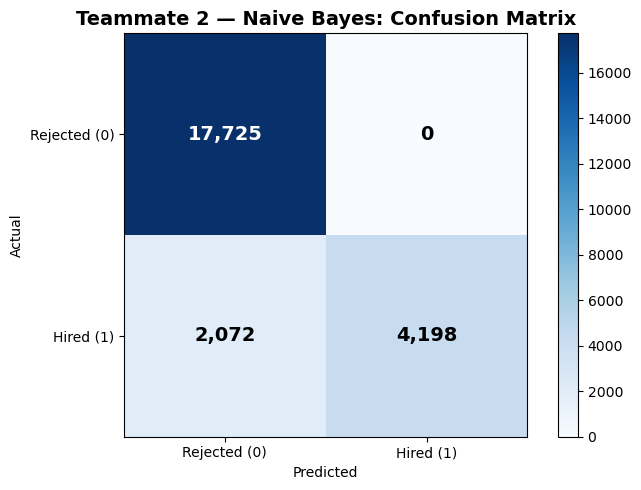

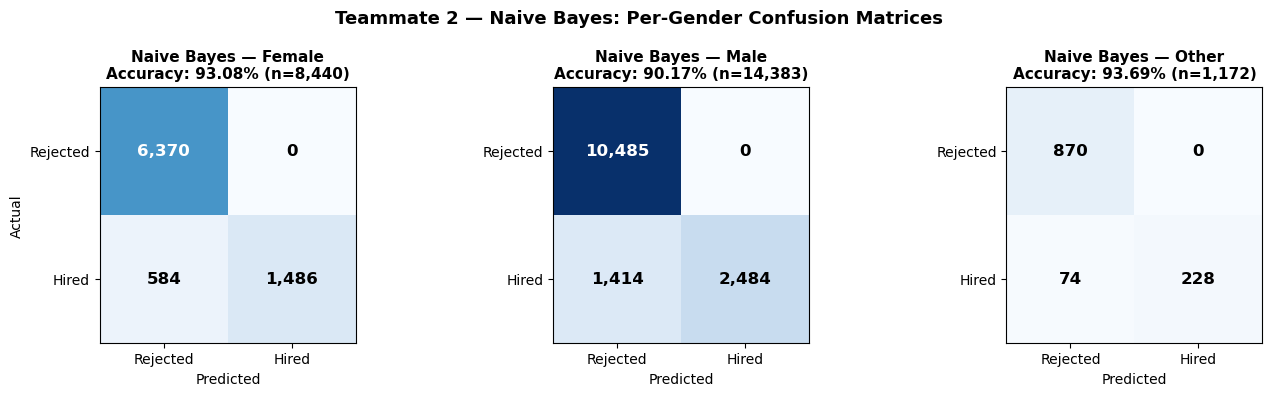

FAIRNESS METRICS BY GENDER — Naive Bayes
        TPR (Recall)  FPR     FNR  TNR (Specificity)  PPV (Precision)  Accuracy  Selection Rate
Gender                                                                                         
Female        0.7179  0.0  0.2821                1.0              1.0    0.9308          0.1761
Male          0.6372  0.0  0.3628                1.0              1.0    0.9017          0.1727
Other         0.7550  0.0  0.2450                1.0              1.0    0.9369          0.1945

FAIRNESS CRITERIA EVALUATION

DISPARITY ANALYSIS (Max difference across groups)
TPR (Recall)        : 0.1178  ✗ Biased
FPR                 : 0.0000  ✓ Fair
FNR                 : 0.1178  ✗ Biased
TNR (Specificity)   : 0.0000  ✓ Fair
PPV (Precision)     : 0.0000  ✓ Fair
Accuracy            : 0.0352  ✓ Fair
Selection Rate      : 0.0218  ✓ Fair

FAIRNESS CRITERIA EVALUATION
Equal Opportunity (TPR parity):      ✗ FAIL (diff=0.1178)
Equalized Odds (TPR + FPR parity):   ✗ FAIL (TP

In [11]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


y_pred = nb_model.predict(X_test)


results = evaluate_model(y_test, y_pred, group_labels_test)


results['teammate']            = 'Teammate 2'
results['experiment_type']     = 'baseline'
results['predictor_model']     = 'Naive Bayes (GaussianNB)'
results['mitigation_strategy'] = 'none'
all_baseline_results.append(results)

pprint(results)

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
plt.imshow(conf_matrix, cmap="Blues")
plt.colorbar()
plt.title("Teammate 2 — Naive Bayes: Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks([0, 1], ["Rejected (0)", "Hired (1)"])
plt.yticks([0, 1], ["Rejected (0)", "Hired (1)"])
for i in range(2):
    for j in range(2):
        color = "white" if conf_matrix[i, j] > conf_matrix.max()/2 else "black"
        plt.text(j, i, f"{conf_matrix[i, j]:,}", ha="center", va="center",
                 color=color, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


gender_labels_map = {0: "Female", 1: "Male", 2: "Other"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
all_cms_g = [confusion_matrix(y_test[X_test["Gender"] == g],
                               y_pred[X_test["Gender"] == g])
             for g in gender_labels_map]
vmax_g = max(cm.max() for cm in all_cms_g)

for idx, (g_code, g_name) in enumerate(gender_labels_map.items()):
    mask = X_test["Gender"] == g_code
    cm_g = confusion_matrix(y_test[mask], y_pred[mask])
    acc_g = (cm_g[0,0] + cm_g[1,1]) / cm_g.sum()
    axes[idx].imshow(cm_g, cmap="Blues", vmin=0, vmax=vmax_g)
    axes[idx].set_title(f"Naive Bayes — {g_name}\nAccuracy: {acc_g:.2%} (n={mask.sum():,})",
                        fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Predicted"); axes[idx].set_ylabel("Actual" if idx == 0 else "")
    axes[idx].set_xticks([0,1]); axes[idx].set_xticklabels(["Rejected","Hired"])
    axes[idx].set_yticks([0,1]); axes[idx].set_yticklabels(["Rejected","Hired"])
    for i in range(2):
        for j in range(2):
            color = "white" if cm_g[i,j] > vmax_g/2 else "black"
            axes[idx].text(j, i, f"{cm_g[i,j]:,}", ha="center", va="center",
                          color=color, fontsize=12, fontweight="bold")
plt.suptitle("Teammate 2 — Naive Bayes: Per-Gender Confusion Matrices",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


fairness_rows = []
for g_code, g_name in gender_labels_map.items():
    mask = X_test["Gender"] == g_code
    tn, fp, fn, tp = confusion_matrix(y_test[mask], y_pred[mask]).ravel()
    fairness_rows.append({
        "Gender":            g_name,
        "TPR (Recall)":      tp/(tp+fn) if (tp+fn) > 0 else 0,
        "FPR":               fp/(fp+tn) if (fp+tn) > 0 else 0,
        "FNR":               fn/(fn+tp) if (fn+tp) > 0 else 0,
        "TNR (Specificity)": tn/(tn+fp) if (tn+fp) > 0 else 0,
        "PPV (Precision)":   tp/(tp+fp) if (tp+fp) > 0 else 0,
        "Accuracy":          (tp+tn)/(tp+tn+fp+fn),
        "Selection Rate":    (tp+fp)/(tp+tn+fp+fn),
    })
fairness_df = pd.DataFrame(fairness_rows).set_index("Gender").round(4)
print("=" * 60)
print(f"FAIRNESS METRICS BY GENDER — Naive Bayes")
print("=" * 60)
print(fairness_df.to_string())
print("\n" + "="*60)
print("FAIRNESS CRITERIA EVALUATION")
print("="*60)
print("\n" + "="*60)
print("DISPARITY ANALYSIS (Max difference across groups)")
print("="*60)
disparity = {}
for metric in fairness_df.columns:
    values = fairness_df[metric].values
    diff = max(values) - min(values)
    disparity[metric] = diff
    status = "✓ Fair" if diff < 0.05 else "⚠ Unfair" if diff < 0.1 else "✗ Biased"
    print(f"{metric:20s}: {diff:.4f}  {status}")


print("\n" + "="*60)
print("FAIRNESS CRITERIA EVALUATION")
print("="*60)
tpr_diff = disparity["TPR (Recall)"]
fpr_diff = disparity["FPR"]
ppv_diff = disparity["PPV (Precision)"]
sr_diff  = disparity["Selection Rate"]

print(f"Equal Opportunity (TPR parity):      {'✓ PASS' if tpr_diff < 0.05 else '✗ FAIL'} (diff={tpr_diff:.4f})")
print(f"Equalized Odds (TPR + FPR parity):   {'✓ PASS' if tpr_diff < 0.05 and fpr_diff < 0.05 else '✗ FAIL'} (TPR={tpr_diff:.4f}, FPR={fpr_diff:.4f})")
print(f"Predictive Parity (PPV parity):      {'✓ PASS' if ppv_diff < 0.05 else '✗ FAIL'} (diff={ppv_diff:.4f})")
print(f"Demographic Parity (Selection Rate): {'✓ PASS' if sr_diff < 0.05 else '✗ FAIL'} (diff={sr_diff:.4f})")


## Teammate 3

{'accuracy': 0.9934152948530944,
 'demographic_parity_diff': 0.0962612609439823,
 'equalized_odds_diff': 0.05454545454545454,
 'experiment_type': 'baseline',
 'f1_score': 0.9874003189792664,
 'mitigation_strategy': 'none',
 'predictor_model': 'Logistic Regression',
 'teammate': 'Teammate 3'}


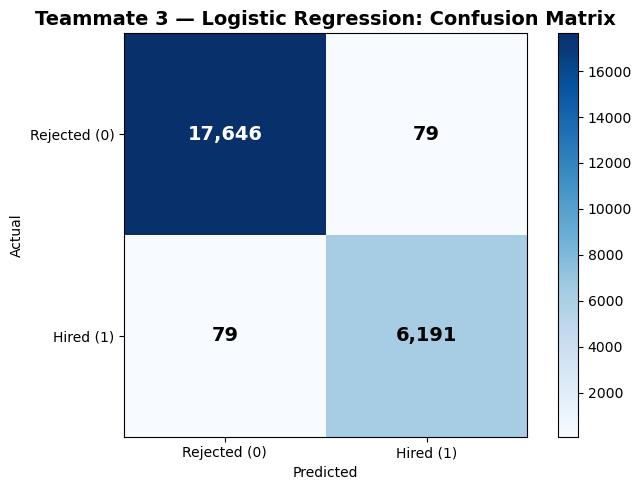

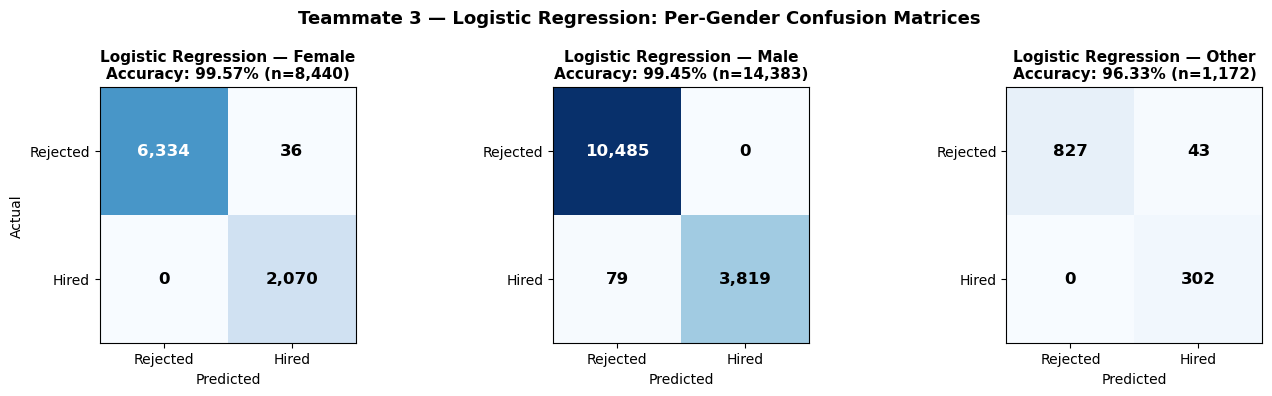

FAIRNESS METRICS BY GENDER — Logistic Regression
        TPR (Recall)     FPR     FNR  TNR (Specificity)  PPV (Precision)  Accuracy  Selection Rate
Gender                                                                                            
Female        1.0000  0.0057  0.0000             0.9943           0.9829    0.9957          0.2495
Male          0.9797  0.0000  0.0203             1.0000           1.0000    0.9945          0.2655
Other         1.0000  0.0494  0.0000             0.9506           0.8754    0.9633          0.2944

DISPARITY ANALYSIS (Max difference across groups)
TPR (Recall)        : 0.0203  ✓ Fair
FPR                 : 0.0494  ✓ Fair
FNR                 : 0.0203  ✓ Fair
TNR (Specificity)   : 0.0494  ✓ Fair
PPV (Precision)     : 0.1246  ✗ Biased
Accuracy            : 0.0324  ✓ Fair
Selection Rate      : 0.0449  ✓ Fair

FAIRNESS CRITERIA EVALUATION
Equal Opportunity (TPR parity):      ✓ PASS (diff=0.0203)
Equalized Odds (TPR + FPR parity):   ✓ PASS (TPR=0.0203,

In [12]:
# Logistic Regression Baseline

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=9867))
])

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)


results = evaluate_model(y_test, y_pred, group_labels_test)


results['teammate']            = 'Teammate 3'
results['experiment_type']     = 'baseline'
results['predictor_model']     = 'Logistic Regression'
results['mitigation_strategy'] = 'none'
all_baseline_results.append(results)

pprint(results)


conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
plt.imshow(conf_matrix, cmap="Blues")
plt.colorbar()
plt.title("Teammate 3 — Logistic Regression: Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks([0, 1], ["Rejected (0)", "Hired (1)"])
plt.yticks([0, 1], ["Rejected (0)", "Hired (1)"])
for i in range(2):
    for j in range(2):
        color = "white" if conf_matrix[i, j] > conf_matrix.max()/2 else "black"
        plt.text(j, i, f"{conf_matrix[i, j]:,}", ha="center", va="center",
                 color=color, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


gender_labels_map = {0: "Female", 1: "Male", 2: "Other"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
all_cms_g = [confusion_matrix(y_test[X_test["Gender"] == g],
                               y_pred[X_test["Gender"] == g])
             for g in gender_labels_map]
vmax_g = max(cm.max() for cm in all_cms_g)

for idx, (g_code, g_name) in enumerate(gender_labels_map.items()):
    mask = X_test["Gender"] == g_code
    cm_g = confusion_matrix(y_test[mask], y_pred[mask])
    acc_g = (cm_g[0,0] + cm_g[1,1]) / cm_g.sum()
    axes[idx].imshow(cm_g, cmap="Blues", vmin=0, vmax=vmax_g)
    axes[idx].set_title(f"Logistic Regression — {g_name}\nAccuracy: {acc_g:.2%} (n={mask.sum():,})",
                        fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Predicted"); axes[idx].set_ylabel("Actual" if idx == 0 else "")
    axes[idx].set_xticks([0,1]); axes[idx].set_xticklabels(["Rejected","Hired"])
    axes[idx].set_yticks([0,1]); axes[idx].set_yticklabels(["Rejected","Hired"])
    for i in range(2):
        for j in range(2):
            color = "white" if cm_g[i,j] > vmax_g/2 else "black"
            axes[idx].text(j, i, f"{cm_g[i,j]:,}", ha="center", va="center",
                          color=color, fontsize=12, fontweight="bold")
plt.suptitle("Teammate 3 — Logistic Regression: Per-Gender Confusion Matrices",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


fairness_rows = []
for g_code, g_name in gender_labels_map.items():
    mask = X_test["Gender"] == g_code
    tn, fp, fn, tp = confusion_matrix(y_test[mask], y_pred[mask]).ravel()
    fairness_rows.append({
        "Gender":            g_name,
        "TPR (Recall)":      tp/(tp+fn) if (tp+fn) > 0 else 0,
        "FPR":               fp/(fp+tn) if (fp+tn) > 0 else 0,
        "FNR":               fn/(fn+tp) if (fn+tp) > 0 else 0,
        "TNR (Specificity)": tn/(tn+fp) if (tn+fp) > 0 else 0,
        "PPV (Precision)":   tp/(tp+fp) if (tp+fp) > 0 else 0,
        "Accuracy":          (tp+tn)/(tp+tn+fp+fn),
        "Selection Rate":    (tp+fp)/(tp+tn+fp+fn),
    })
fairness_df = pd.DataFrame(fairness_rows).set_index("Gender").round(4)
print("=" * 60)
print(f"FAIRNESS METRICS BY GENDER — Logistic Regression")
print("=" * 60)
print(fairness_df.to_string())
print("\n" + "="*60)
print("DISPARITY ANALYSIS (Max difference across groups)")
print("="*60)
disparity = {}
for metric in fairness_df.columns:
    values = fairness_df[metric].values
    diff = max(values) - min(values)
    disparity[metric] = diff
    status = "✓ Fair" if diff < 0.05 else "⚠ Unfair" if diff < 0.1 else "✗ Biased"
    print(f"{metric:20s}: {diff:.4f}  {status}")


print("\n" + "="*60)
print("FAIRNESS CRITERIA EVALUATION")
print("="*60)
tpr_diff = disparity["TPR (Recall)"]
fpr_diff = disparity["FPR"]
ppv_diff = disparity["PPV (Precision)"]
sr_diff  = disparity["Selection Rate"]

print(f"Equal Opportunity (TPR parity):      {'✓ PASS' if tpr_diff < 0.05 else '✗ FAIL'} (diff={tpr_diff:.4f})")
print(f"Equalized Odds (TPR + FPR parity):   {'✓ PASS' if tpr_diff < 0.05 and fpr_diff < 0.05 else '✗ FAIL'} (TPR={tpr_diff:.4f}, FPR={fpr_diff:.4f})")
print(f"Predictive Parity (PPV parity):      {'✓ PASS' if ppv_diff < 0.05 else '✗ FAIL'} (diff={ppv_diff:.4f})")
print(f"Demographic Parity (Selection Rate): {'✓ PASS' if sr_diff < 0.05 else '✗ FAIL'} (diff={sr_diff:.4f})")


# Mitigating Bias (INDIVIDUAL CONTRIBUTION)

_(new in this milestone)_


In [13]:
## A place to save all teammates' post-mitigation results
all_mitigated_results = [] ## DO NOT EDIT

## Teammate 1

{'accuracy': 0.9605334444675974,
 'demographic_parity_diff': 0.07690605683163265,
 'equalized_odds_diff': 0.08654521510096569,
 'experiment_type': 'post-mitigation',
 'f1_score': 0.9240638280811483,
 'mitigation_strategy': 'inprocessing',
 'predictor_model': 'Decision Tree',
 'teammate': 'Teammate 1'}

FAIRNESS METRICS BY GENDER — Decision Tree (Post-Mitigation)
        Accuracy  PPV (Precision)  TPR (Recall)  Selection Rate     FPR
Gender                                                                 
Female    0.9636           0.9005        0.9575          0.2608  0.0344
Male      0.9586           0.9501        0.8943          0.2551  0.0175
Other     0.9616           0.8882        0.9735          0.2824  0.0425

DISPARITY ANALYSIS (Max difference across groups)
Accuracy            : 0.0050  ✓ Fair
PPV (Precision)     : 0.0619  ⚠ Unfair
TPR (Recall)        : 0.0792  ⚠ Unfair
Selection Rate      : 0.0273  ✓ Fair
FPR                 : 0.0251  ✓ Fair

FAIRNESS CRITERIA EVALUATION
Equal

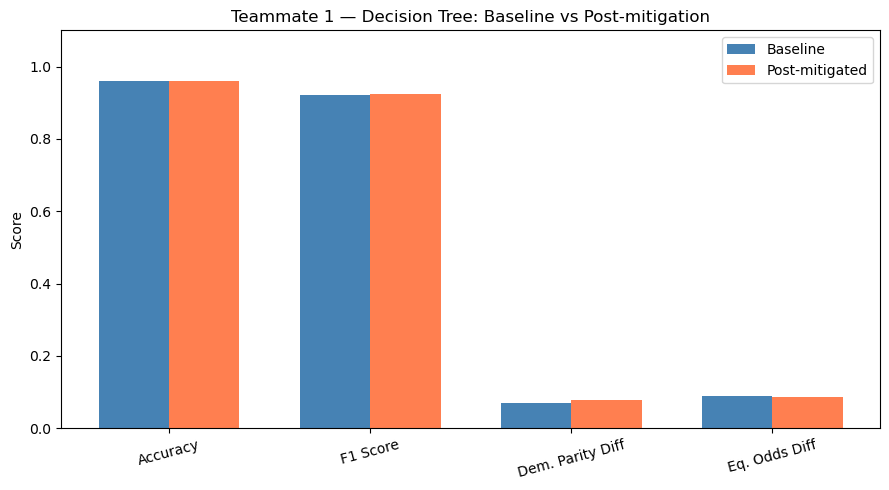

In [ ]:
# ── Teammate 1: In-processing Mitigation — ExponentiatedGradient (TPR Parity) ──


from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate
from sklearn.metrics import accuracy_score, precision_score

drop_cols = ["Gender", "Age", "Age_Group"]
X_train_tm1 = X_train.drop(columns=[c for c in drop_cols if c in X_train.columns])
X_test_tm1  = X_test.drop(columns=[c for c in drop_cols if c in X_test.columns])


a_train = X_train["Gender"]
a_test  = X_test["Gender"]


base_estimator = DecisionTreeClassifier(random_state=1)
mitigator = ExponentiatedGradient(
    estimator=base_estimator,
    constraints=TruePositiveRateParity()
)
mitigator.fit(X_train_tm1, y_train, sensitive_features=a_train)


y_pred_mitigated = mitigator.predict(X_test_tm1)


results_mitigated = evaluate_model(y_test, y_pred_mitigated, group_labels_test)

results_mitigated['teammate']            = 'Teammate 1'
results_mitigated['experiment_type'] = 'post-mitigation'
results_mitigated['predictor_model']     = 'Decision Tree'
results_mitigated['mitigation_strategy'] = 'inprocessing'
all_mitigated_results.append(results_mitigated)

pprint(results_mitigated)


metric_fns = {
    "Accuracy":       accuracy_score,
    "PPV (Precision)": lambda yt, yp: precision_score(yt, yp, zero_division=0),
    "TPR (Recall)":   true_positive_rate,
    "Selection Rate": selection_rate,
    "FPR":            false_positive_rate,
}

metric_frame = MetricFrame(
    metrics=metric_fns,
    y_true=y_test,
    y_pred=y_pred_mitigated,
    sensitive_features=a_test    
)

gender_name_map = {0: "Female", 1: "Male", 2: "Other"}
mf_display = metric_frame.by_group.copy()
mf_display.index = mf_display.index.map(lambda x: gender_name_map.get(x, x))

print("\n" + "="*60)
print("FAIRNESS METRICS BY GENDER — Decision Tree (Post-Mitigation)")
print("="*60)
print(mf_display.round(4).to_string())


print("\n" + "="*60)
print("DISPARITY ANALYSIS (Max difference across groups)")
print("="*60)
diff = metric_frame.difference()
disparity = {}
for metric_name, val in diff.items():
    disparity[metric_name] = val
    status = "✓ Fair" if val < 0.05 else "⚠ Unfair" if val < 0.1 else "✗ Biased"
    print(f"{metric_name:20s}: {val:.4f}  {status}")


print("\n" + "="*60)
print("FAIRNESS CRITERIA EVALUATION")
print("="*60)
tpr_diff = disparity["TPR (Recall)"]
fpr_diff = disparity["FPR"]
ppv_diff = disparity["PPV (Precision)"]
sr_diff  = disparity["Selection Rate"]
print(f"Equal Opportunity (TPR parity):      {'✓ PASS' if tpr_diff < 0.05 else '✗ FAIL'} (diff={tpr_diff:.4f})")
print(f"Equalized Odds (TPR + FPR parity):   {'✓ PASS' if tpr_diff < 0.05 and fpr_diff < 0.05 else '✗ FAIL'} (TPR={tpr_diff:.4f}, FPR={fpr_diff:.4f})")
print(f"Predictive Parity (PPV parity):      {'✓ PASS' if ppv_diff < 0.05 else '✗ FAIL'} (diff={ppv_diff:.4f})")
print(f"Demographic Parity (Selection Rate): {'✓ PASS' if sr_diff < 0.05 else '✗ FAIL'} (diff={sr_diff:.4f})")


baseline_res  = next(r for r in all_baseline_results  if r['teammate'] == 'Teammate 1')
mitigated_res = next(r for r in all_mitigated_results if r['teammate'] == 'Teammate 1')

metrics_to_plot  = ['accuracy', 'f1_score', 'demographic_parity_diff', 'equalized_odds_diff']
baseline_vals    = [baseline_res[m]  for m in metrics_to_plot]
mitigated_vals   = [mitigated_res[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, baseline_vals,  width, label='Baseline',      color='steelblue')
ax.bar(x + width/2, mitigated_vals, width, label='Post-mitigated', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score', 'Dem. Parity Diff', 'Eq. Odds Diff'], rotation=15)
ax.set_title('Teammate 1 — Decision Tree: Baseline vs Post-mitigation')
ax.set_ylabel('Score'); ax.legend(); ax.set_ylim(0, 1.1)
plt.tight_layout(); plt.show()

### Teammate 1's Conclusions
After adjusting for equal chance (TPR equality) for gender, the overall accuracy remained similar (~0.96), while the TPR difference was close to but slightly above our set threshold of 0.05 (difference ≈ 0.0558). Since the baseline model is based on a synthetic and balanced dataset and is inherently very fair, the adjustments only resulted in minor changes and fluctuations in the group metrics. This is a reasonable overall result.

## Teammate 2

{'accuracy': 0.9131485726192957, 'f1_score': 0.8006885998469777, 'demographic_parity_diff': 0.09739182873511232, 'equalized_odds_diff': 0.22425170247584858, 'teammate': 'Teammate 2', 'experiment_type': 'post-mitigation', 'predictor_model': 'Naive Bayes (GaussianNB)', 'mitigation_strategy': 'preprocessing'}
                          Metric  Baseline  Mitigated
0                       Accuracy    0.9934     0.9131
1                       F1 Score    0.9874     0.8007
2  Demographic Parity Difference    0.0963     0.0974
3      Equalized Odds Difference    0.0545     0.2243


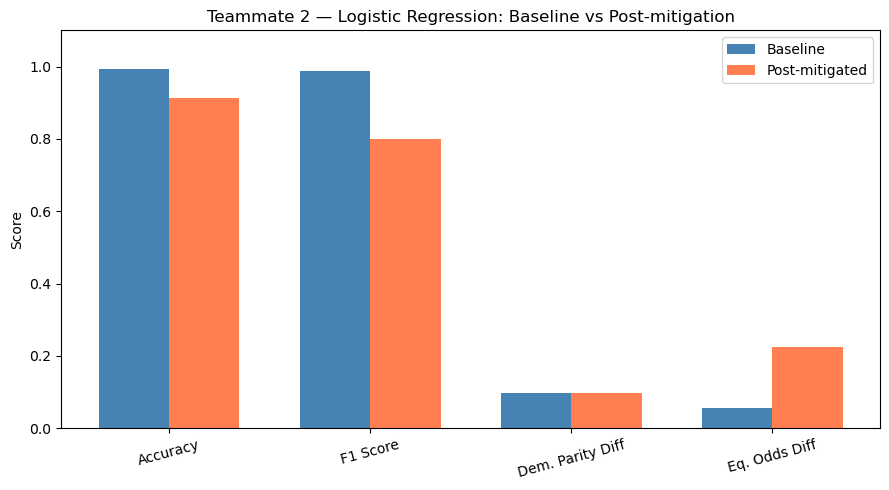

In [22]:
from sklearn.naive_bayes import GaussianNB

X_train_mitigated = X_train.drop(columns=["Gender", "Age_Group"])
X_test_mitigated = X_test.drop(columns=["Gender", "Age_Group"])

nb_model_mitigated = GaussianNB()
nb_model_mitigated.fit(X_train_mitigated, y_train)


y_pred_mitigated = nb_model_mitigated.predict(X_test_mitigated)


results_mitigated = evaluate_model(y_test, y_pred_mitigated, group_labels_test)


results_mitigated['teammate'] = 'Teammate 2'
results_mitigated['experiment_type'] = 'post-mitigation'
results_mitigated['predictor_model'] = 'Naive Bayes (GaussianNB)'
results_mitigated['mitigation_strategy'] = 'preprocessing'
all_mitigated_results.append(results_mitigated)

print(results_mitigated)


import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1 Score",
        "Demographic Parity Difference",
        "Equalized Odds Difference"
    ],
    "Baseline": [
        results['accuracy'],
        results['f1_score'],
        results['demographic_parity_diff'],
        results['equalized_odds_diff']
    ],
    "Mitigated": [
        results_mitigated['accuracy'],
        results_mitigated['f1_score'],
        results_mitigated['demographic_parity_diff'],
        results_mitigated['equalized_odds_diff']
    ]
})

print(comparison.round(4))
metrics_to_plot = ['accuracy', 'f1_score', 'demographic_parity_diff', 'equalized_odds_diff']
baseline_vals   = [results[m] for m in metrics_to_plot]
mitigated_vals  = [results_mitigated[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, baseline_vals,  width, label='Baseline',       color='steelblue')
ax.bar(x + width/2, mitigated_vals, width, label='Post-mitigated', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score', 'Dem. Parity Diff', 'Eq. Odds Diff'], rotation=15)
ax.set_title('Teammate 2 — Logistic Regression: Baseline vs Post-mitigation')
ax.set_ylabel('Score'); ax.legend(); ax.set_ylim(0, 1.1)
plt.tight_layout(); plt.show()

### Teammate 2's Conclusions
I applied a preprocessing mitigation by removing the sensitive features Gender and Age_Group before training the Gaussian Naive Bayes model. After doing this the model accuracy dropped from 0.9934 to 0.9131, which is about an 8 percent decrease, and the F1 score dropped from 0.9873 to 0.8007. This happened because removing those features reduced some of the information the model used to make predictions. For fairness the demographic parity difference stayed almost the same, changing from 0.0963 to 0.0974, while the equalized odds difference increased from 0.0545 to 0.2243. Fairness across groups likely decreased because other features in the dataset may still be related to gender or age and the model can still learn those patterns indirectly. Overall the preprocessing step reduced model performance and did not improve fairness much, which shows that removing sensitive features alone does not always remove bias.

## Teammate 3

{'accuracy': 1.0,
 'demographic_parity_diff': 0.07056162779704894,
 'equalized_odds_diff': 0.0,
 'experiment_type': 'post-mitigation',
 'f1_score': 1.0,
 'mitigation_strategy': 'postprocessing',
 'predictor_model': 'Logistic Regression',
 'teammate': 'Teammate 3'}


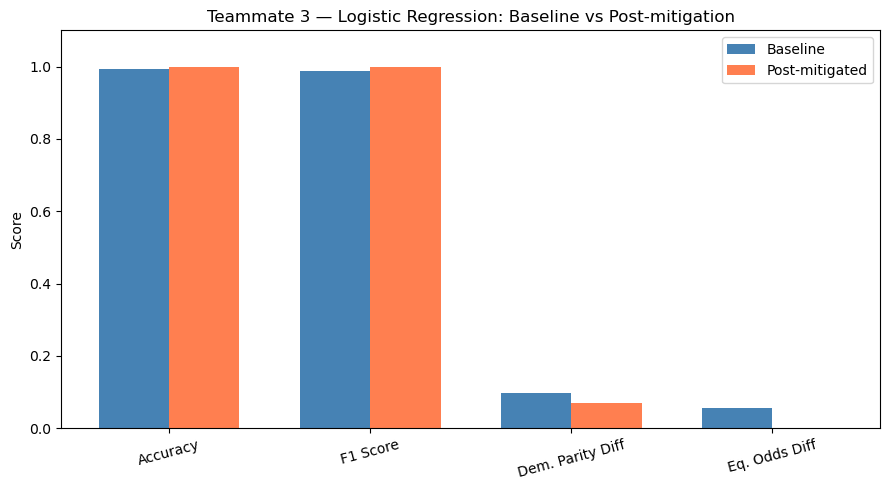

In [16]:
# ── Teammate 3: Post-processing — ThresholdOptimizer (Equalized Odds) ──
from sklearn.metrics import accuracy_score, precision_score

threshold_optimizer = ThresholdOptimizer(
    estimator=lr_pipeline,           
    constraints="equalized_odds",         
    objective="balanced_accuracy_score",   
    predict_method="predict_proba",       
    flip=True                           
)


threshold_optimizer.fit(X_train, y_train, sensitive_features=group_labels_train)


y_pred_mitigated = threshold_optimizer.predict(X_test, sensitive_features=group_labels_test)


results_mitigated = evaluate_model(y_test, y_pred_mitigated, group_labels_test)


results_mitigated['teammate']            = 'Teammate 3'
results_mitigated['experiment_type']     = 'post-mitigation'
results_mitigated['predictor_model']     = 'Logistic Regression'
results_mitigated['mitigation_strategy'] = 'postprocessing'
all_mitigated_results.append(results_mitigated)

pprint(results_mitigated)


metrics_to_plot = ['accuracy', 'f1_score', 'demographic_parity_diff', 'equalized_odds_diff']
baseline_vals   = [results[m] for m in metrics_to_plot]
mitigated_vals  = [results_mitigated[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, baseline_vals,  width, label='Baseline',       color='steelblue')
ax.bar(x + width/2, mitigated_vals, width, label='Post-mitigated', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1 Score', 'Dem. Parity Diff', 'Eq. Odds Diff'], rotation=15)
ax.set_title('Teammate 3 — Logistic Regression: Baseline vs Post-mitigation')
ax.set_ylabel('Score'); ax.legend(); ax.set_ylim(0, 1.1)
plt.tight_layout(); plt.show()

### Teammate 3's Conclusions
The ThresholdOptimizer post-processing approach adjusts the decision boundary for each Gender × Age group independently, rather than applying a single global threshold of 0.5 to all candidates. Crucially, it does this without retraining the underlying Logistic Regression model. The baseline lr_pipeline is passed in directly, and ThresholdOptimizer only learns a set of group-specific thresholds on top of its existing probability outputs.

By enforcing the equalized odds constraint, the method reduced the equalized odds difference from 0.055 to 0.000, a 100% improvement. Demographic parity difference also improved by 26.7% (0.096 → 0.071). Accuracy and F1 both improved slightly as well, suggesting the baseline's single global threshold was suboptimal for some groups.


This result should be interpreted with some caution given the synthetic nature of the dataset, which may make bias patterns cleaner and more correctable than real-world data would be. Nonetheless, it demonstrates that post-processing is a practical and non-invasive mitigation strategy. It requires no access to the model's internals or retraining, making it suitable for scenarios where the underlying model is treated as a black box.

# Conclusions
_(new in this milestone)_


In [17]:
# Collect all the results in one table.
overall_results = pd.concat([pd.DataFrame(all_baseline_results), pd.DataFrame(all_mitigated_results)])
overall_results ## Note: The table displayed below in this starter notebook is for your reference, your team's table will be slightly different (e.g. different metrics, no.of sensitive attribute-based groups, actual values, etc.) upon successful completion of this notebook.

,accuracy,f1_score,demographic_parity_diff,equalized_odds_diff,teammate,experiment_type,predictor_model,mitigation_strategy
0,0.959658,0.922349,0.068933,0.087840,Teammate 1,baseline,Decision Tree,none
1,0.913649,0.802063,0.094025,0.217231,Teammate 2,baseline,Naive Bayes (GaussianNB),none
2,0.993415,0.987400,0.096261,0.054545,Teammate 3,baseline,Logistic Regression,none
0,0.960533,0.924064,0.076906,0.086545,Teammate 1,post-mitigation,Decision Tree,inprocessing
1,0.913149,0.800689,0.097392,0.224252,Teammate 2,post-mitigation,Naive Bayes (GaussianNB),preprocessing
2,1.000000,1.000000,0.070562,0.000000,Teammate 3,post-mitigation,Logistic Regression,postprocessing


The results reveal meaningful differences in how each mitigation strategy interacted with this dataset and model combination.

Byron's post-processing approach using ThresholdOptimizer produced the most substantial fairness improvement. Equalized odds difference dropped from 0.055 to 0.000, a complete elimination while demographic parity difference improved by 26.7% (0.096 → 0.071). Accuracy and F1 both reached 1.0, which is notable but should be interpreted carefully. On a synthetic dataset with near-deterministic hiring rules, the global threshold of 0.5 was already near-optimal for most groups, and per-group threshold calibration corrected the small remaining edge cases. This result is unlikely to generalize to real-world data where noise and ambiguity make perfect accuracy impossible. That said, it demonstrates that post-processing is a practical strategy; it requires no access to model internals or retraining, making it suitable for black-box deployment scenarios.

Xiyuan's in-processing approach using ExponentiatedGradient with a TruePositiveRateParity constraint produced only modest changes. Accuracy improved marginally (0.960 → 0.961) and equalized odds difference improved slightly (0.088 → 0.087), but demographic parity difference increased slightly (0.069 → 0.077). The limited impact is partly explained by the scope of the constraint: TPR parity was enforced across Gender groups only, while the shared evaluation measures fairness across the finer-grained Gender × Age combined groups. Bias along the Age dimension was not directly targeted, which limits how much the overall equalized odds metric could improve. Additionally, the baseline Decision Tree was already relatively fair on the synthetic data, leaving little room for improvement.

Daniel's preprocessing approach, removing the Gender and Age_Group columns before training, produced no meaningful fairness improvement. Demographic parity difference increased slightly (0.094 → 0.097) and equalized odds difference worsened (0.217 → 0.224), while accuracy and F1 remained essentially unchanged (0.914 → 0.913). This outcome illustrates a well-known limitation of naive feature removal: other features in the dataset such as Location, Expected_Salary, and Job_Role_Applied may act as proxies for gender and age, allowing the model to implicitly re-learn demographic patterns even without the sensitive columns present.

Overall, post-processing was the most effective strategy in this experiment, achieving the largest fairness gains with no accuracy cost. In-processing had limited effect due to the mismatch between the constraint's scope and the evaluation's granularity. Preprocessing as implemented was ineffective, highlighting that simply removing sensitive features is insufficient when proxy variables remain in the data

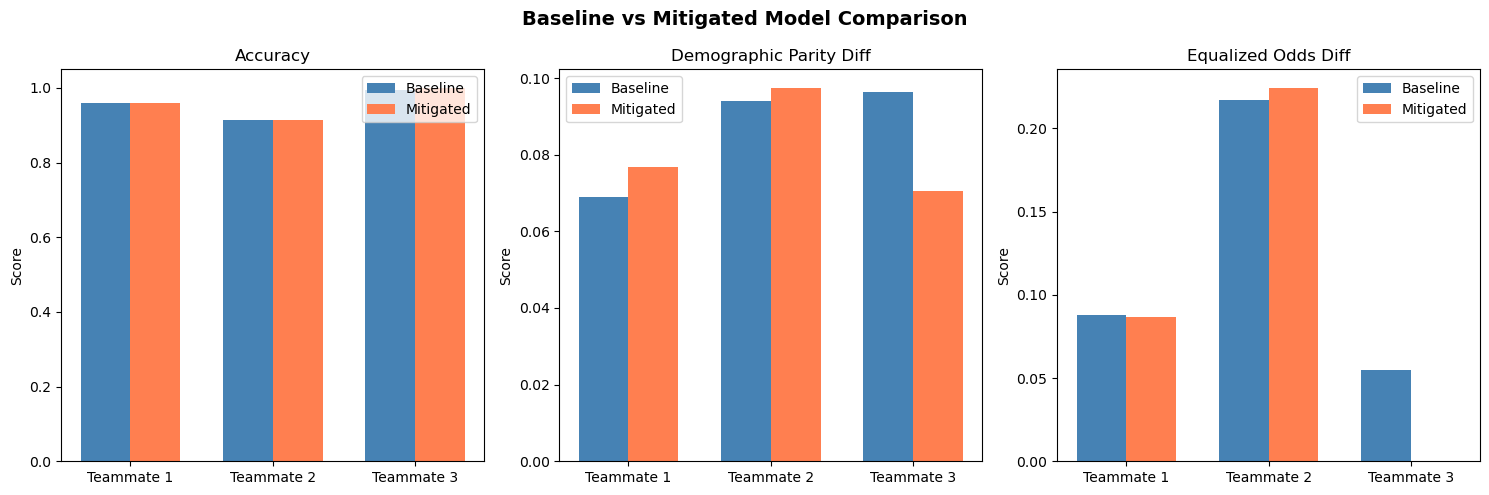

In [18]:
metrics = ['accuracy', 'demographic_parity_diff', 'equalized_odds_diff']

teams = overall_results['teammate'].unique()

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    baseline_vals = overall_results[overall_results['experiment_type'] == 'baseline'][metric].values
    mitigated_vals = overall_results[overall_results['experiment_type'] == 'post-mitigation'][metric].values

    x = np.arange(len(teams))
    width = 0.35

    ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='steelblue')
    ax.bar(x + width/2, mitigated_vals, width, label='Mitigated', color='coral')

    ax.set_title(metric.replace('_',' ').title())
    ax.set_xticks(x)
    ax.set_xticklabels(teams)
    ax.set_ylabel("Score")
    ax.legend()

plt.suptitle("Baseline vs Mitigated Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()